# Adult Income Prediction — Final Validation (Day 5)

Load the Day 4 saved model, score the hold-out test set again, look at mistakes, check feature importance, and try inference.

**Final model:** calibrated HistGradientBoosting, threshold **0.33** (picked on validation for best F1).

## 1. Setup and environment

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

numpy: 2.3.1
pandas: 2.3.0
scikit-learn: 1.9.0


In [2]:
# Same Day 1 hold-out split
adult = fetch_openml("adult", version=2, as_frame=True, parser="auto")
df = adult.frame.copy()
df = df.rename(columns={"class": "income"})
df = df.replace(r"^\s*\?$", np.nan, regex=True)
df["income"] = df["income"].astype(str).map({"<=50K": 0, ">50K": 1})

X = df.drop("income", axis=1)
y = df["income"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train):,} | Hold-out test: {len(X_test):,}")
print(f"Test positive rate: {y_test.mean() * 100:.2f}%")

Train: 39,073 | Hold-out test: 9,769
Test positive rate: 23.93%


## 2. Final model validation

Load `final_model.joblib`, check that reload still works, and score the untouched test set.

In [3]:
artifact = joblib.load("final_model.joblib")
model = artifact["model"]
threshold = artifact["threshold"]

print("Model:", artifact.get("model_name"))
print("Threshold:", threshold)
print("Best params:", artifact.get("best_params"))
print("Dropped features:", artifact.get("dropped_features"))
print("Random state:", artifact.get("random_state"))

# Reload from disk and confirm scores match
reloaded = joblib.load("final_model.joblib")
p1 = model.predict_proba(X_test.iloc[:40])[:, 1]
p2 = reloaded["model"].predict_proba(X_test.iloc[:40])[:, 1]
assert np.allclose(p1, p2), "Reload mismatch"
assert reloaded["threshold"] == threshold
print("Reload OK - same probabilities after joblib.load")

Model: HistGradientBoosting (calibrated)
Threshold: 0.32999999999999996
Best params: {'clf__min_samples_leaf': 10, 'clf__max_iter': 100, 'clf__max_depth': None, 'clf__learning_rate': 0.15, 'clf__l2_regularization': 0.5}
Dropped features: ['fnlwgt']
Random state: 42


Reload OK - same probabilities after joblib.load


In [4]:
proba_test = model.predict_proba(X_test)[:, 1]
y_pred = (proba_test >= threshold).astype(int)

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, proba_test),
    "PR AUC": average_precision_score(y_test, proba_test),
    "Brier": brier_score_loss(y_test, proba_test),
}
pd.DataFrame([final_metrics], index=["Final HGB (calibrated @ 0.33)"]).round(4)

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Brier
Final HGB (calibrated @ 0.33),0.8571,0.6707,0.7917,0.7262,0.9299,0.8343,0.0867


In [5]:
# Comparison across the week (hold-out test where available)
comparison = pd.DataFrame([
    {"Model": "Day 1 Majority Baseline", "F1": 0.0000, "ROC AUC": 0.5000, "Notes": "Always predict <=50K"},
    {"Model": "Day 1 Education Rule", "F1": 0.4906, "ROC AUC": 0.6653, "Notes": "education-num >= 13"},
    {"Model": "Day 2 Logistic Regression", "F1": 0.6630, "ROC AUC": 0.9057, "Notes": "Untuned pipeline"},
    {"Model": "Day 2 Decision Tree", "F1": 0.6251, "ROC AUC": 0.7546, "Notes": "Overfit (depth 68)"},
    {"Model": "Day 3 HGB (CV mean)", "F1": 0.7084, "ROC AUC": 0.9273, "Notes": "Engineered features, untuned"},
    {"Model": "Day 4 HGB uncal @ 0.50", "F1": 0.7155, "ROC AUC": 0.9298, "Notes": "Tuned, default threshold"},
    {"Model": "Day 4/5 Final HGB cal @ 0.33", "F1": final_metrics["F1"], "ROC AUC": final_metrics["ROC AUC"], "Notes": "Calibrated + tuned threshold"},
]).set_index("Model")
comparison.round(4)

,F1,ROC AUC,Notes
Model,,,
Day 1 Majority Baseline,0.0000,0.5000,Always predict <=50K
Day 1 Education Rule,0.4906,0.6653,education-num >= 13
Day 2 Logistic Regression,0.6630,0.9057,Untuned pipeline
Day 2 Decision Tree,0.6251,0.7546,Overfit (depth 68)
Day 3 HGB (CV mean),0.7084,0.9273,"Engineered features, untuned"
Day 4 HGB uncal @ 0.50,0.7155,0.9298,"Tuned, default threshold"
Day 4/5 Final HGB cal @ 0.33,0.7262,0.9299,Calibrated + tuned threshold


### Leakage check

- Same Day 1 stratified 80/20 split (`random_state=42`); test rows were not used for fitting, search, calibration, or picking the threshold.
- Feature engineering is row-level only (no target encoding).
- Imputer / scaler / encoder sit inside the pipeline and were fit on training data only.
- Threshold 0.33 was chosen on a **train** validation slice, then applied once on the hold-out test set.

## 3. Errors and model behavior

TN=6,522  FP=909  FN=487  TP=1,851
False positives are more common than false negatives (909 vs 487).
With F1 as the business metric, both error types matter; FP wastes outreach, FN misses high earners.


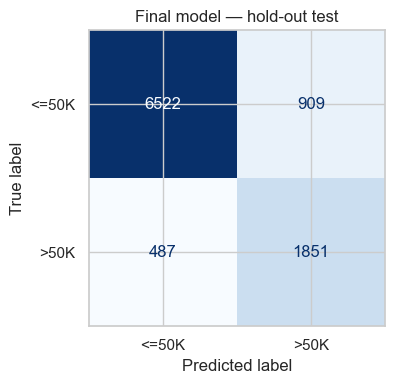

In [6]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"False positives are more common than false negatives ({fp} vs {fn}).")
print("With F1 as the business metric, both error types matter; FP wastes outreach, FN misses high earners.")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["<=50K", ">50K"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Final model — hold-out test")
plt.tight_layout()
plt.show()

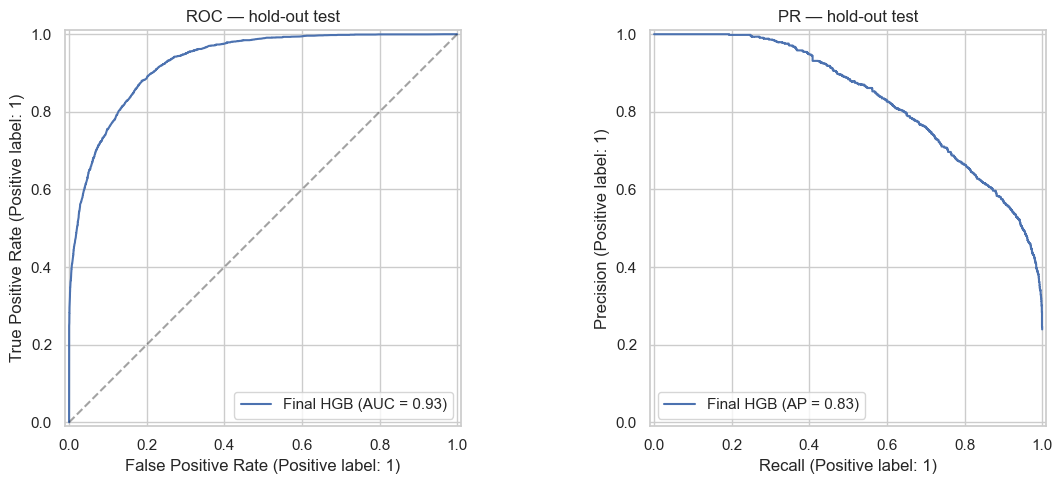

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[0], name="Final HGB")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_title("ROC — hold-out test")
PrecisionRecallDisplay.from_predictions(y_test, proba_test, ax=axes[1], name="Final HGB")
axes[1].set_title("PR — hold-out test")
plt.tight_layout()
plt.show()

In [8]:
analysis = X_test.copy()
analysis["actual"] = y_test.values
analysis["predicted"] = y_pred
analysis["proba"] = proba_test

fp_cases = analysis[(analysis["actual"] == 0) & (analysis["predicted"] == 1)]
fn_cases = analysis[(analysis["actual"] == 1) & (analysis["predicted"] == 0)]
tp_cases = analysis[(analysis["actual"] == 1) & (analysis["predicted"] == 1)]

print("=== False positives (predicted >50K, actually <=50K) ===")
print("Count:", len(fp_cases))
print("Top occupations:\n", fp_cases["occupation"].value_counts().head(5))
print("Marital status:\n", fp_cases["marital-status"].value_counts().head(5))
print(f"Mean age={fp_cases['age'].mean():.1f} | hours={fp_cases['hours-per-week'].mean():.1f} | edu-num={fp_cases['education-num'].mean():.1f}")

print("\n=== False negatives (predicted <=50K, actually >50K) ===")
print("Count:", len(fn_cases))
print("Top occupations:\n", fn_cases["occupation"].value_counts().head(5))
print("Marital status:\n", fn_cases["marital-status"].value_counts().head(5))
print(f"Mean age={fn_cases['age'].mean():.1f} | hours={fn_cases['hours-per-week'].mean():.1f} | edu-num={fn_cases['education-num'].mean():.1f}")

print("\n=== True positives (for contrast) ===")
print(f"Mean age={tp_cases['age'].mean():.1f} | hours={tp_cases['hours-per-week'].mean():.1f} | edu-num={tp_cases['education-num'].mean():.1f}")

=== False positives (predicted >50K, actually <=50K) ===
Count: 909
Top occupations:
 occupation
Exec-managerial    192
Craft-repair       164
Prof-specialty     135
Sales              133
Adm-clerical       102
Name: count, dtype: int64
Marital status:
 marital-status
Married-civ-spouse    850
Never-married          28
Divorced               18
Widowed                 5
Separated               5
Name: count, dtype: int64
Mean age=44.3 | hours=45.1 | edu-num=11.1

=== False negatives (predicted <=50K, actually >50K) ===
Count: 487
Top occupations:
 occupation
Craft-repair        98
Prof-specialty      56
Sales               52
Exec-managerial     47
Transport-moving    40
Name: count, dtype: int64
Marital status:
 marital-status
Married-civ-spouse    321
Never-married          77
Divorced               59
Separated              12
Widowed                11
Name: count, dtype: int64
Mean age=41.8 | hours=43.8 | edu-num=9.8

=== True positives (for contrast) ===
Mean age=44.5 | hours=46.

In [9]:
# Subgroup check: recall on positives and accuracy
rows = []
for col in ["sex", "marital-status", "race"]:
    for group, part in analysis.groupby(col, observed=False):
        if len(part) < 80:
            continue
        acc = (part["actual"] == part["predicted"]).mean()
        pos = part["actual"] == 1
        rec = ((part["predicted"] == 1) & pos).sum() / pos.sum() if pos.sum() else np.nan
        rows.append({"feature": col, "group": str(group), "n": len(part), "accuracy": acc, "recall": rec})

subgroup = pd.DataFrame(rows)
display(subgroup.round(3))

,feature,group,n,accuracy,recall
0,sex,Female,3259,0.931,0.717
1,sex,Male,6510,0.820,0.805
2,marital-status,Divorced,1326,0.942,0.572
3,marital-status,Married-civ-spouse,4537,0.742,0.838
4,marital-status,Married-spouse-absent,124,0.919,0.500
5,marital-status,Never-married,3186,0.967,0.522
6,marital-status,Separated,292,0.942,0.250
7,marital-status,Widowed,297,0.946,0.476
8,race,Amer-Indian-Eskimo,96,0.906,0.538
9,race,Asian-Pac-Islander,311,0.804,0.768


### What the mistakes look like

- Predictions are stronger when capital-gain, education, and marital status line up with high-income patterns (same idea as Day 1–2).
- **False positives** often look “high status” on paper (married, Exec-managerial / Sales / Prof-specialty) but still earn <=50K. The 0.33 threshold creates more of these than 0.50.
- **False negatives** include high earners in Craft-repair / Transport-moving and some Never-married / Divorced cases where education alone is not high.
- For outreach, missing a high earner (**FN**) usually hurts more, so the threshold leans toward recall. If false alarms cost more, raise it.

**Ideas to try next:** better occupation × education features, sharper capital-gain handling, fairness checks by sex/race, or a cost-based threshold.

## 4. Feature importance

HistGradientBoosting does not give easy coefficients, so I use **permutation importance** on a hold-out sample (F1 at threshold 0.33).

In [10]:
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=1500, replace=False)
X_s = X_test.iloc[sample_idx]
y_s = y_test.iloc[sample_idx]

def f1_at_threshold(estimator, X_in, y_in):
    p = estimator.predict_proba(X_in)[:, 1]
    return f1_score(y_in, (p >= threshold).astype(int))

imp_result = permutation_importance(
    model, X_s, y_s,
    scoring=f1_at_threshold,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance": imp_result.importances_mean,
        "std": imp_result.importances_std,
    })
    .sort_values("importance", ascending=False)
)
display(importance_df.head(12).round(4))

,feature,importance,std
5,marital-status,0.1493,0.0142
10,capital-gain,0.0894,0.0048
0,age,0.0474,0.0117
4,education-num,0.0429,0.0092
11,capital-loss,0.0157,0.0038
6,occupation,0.0124,0.0064
1,workclass,0.0076,0.0049
12,hours-per-week,0.0062,0.0048
7,relationship,0.0037,0.0028
3,education,0.0033,0.0026


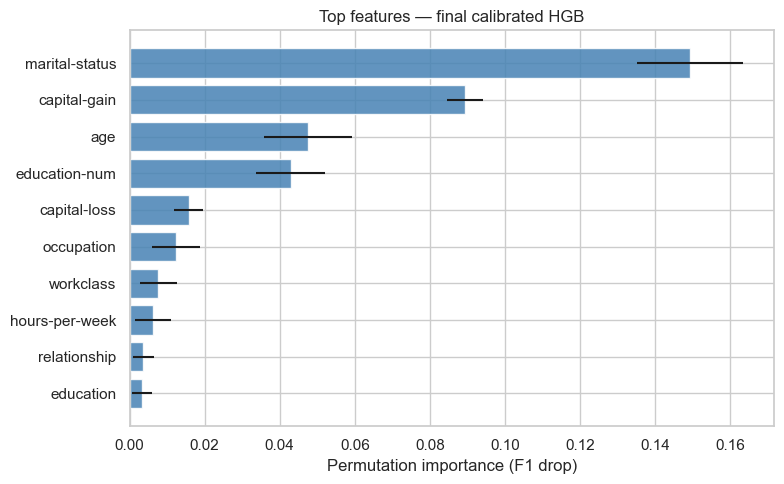

In [11]:
top = importance_df.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["feature"], top["importance"], xerr=top["std"], color="steelblue", alpha=0.85)
ax.set_xlabel("Permutation importance (F1 drop)")
ax.set_title("Top features — final calibrated HGB")
plt.tight_layout()
plt.show()

### Reading the importance plot

- **`marital-status`** and **`capital-gain`** matter most — married + capital activity push toward >50K.
- **`age`** and **`education-num`** come next (fits the Day 1 education rule and mid-career patterns).
- **`occupation` / `workclass` / `hours-per-week`** help a bit less but still matter.
- One caution: marital status can stand in for other demographics, so treat it as a correlation, not a fair rule for targeting. `fnlwgt` was already dropped because it is a sampling weight.

## 5. Inference

Preprocessing is already inside the saved pipeline. New rows just need the same raw Adult columns.

In [12]:
def predict_income(new_data, artifact_path="final_model.joblib"):
    """Run inference with the saved calibrated pipeline + threshold."""
    art = joblib.load(artifact_path)
    est = art["model"]
    thr = art["threshold"]
    if isinstance(new_data, dict):
        new_data = pd.DataFrame([new_data])
    proba = est.predict_proba(new_data)[:, 1]
    pred = (proba >= thr).astype(int)
    return pd.DataFrame({
        "prediction": pred,
        "probability_over_50k": proba,
        "label": np.where(pred == 1, ">50K", "<=50K"),
    })


# 10 hold-out examples (unseen during training)
demo = X_test.sample(10, random_state=RANDOM_STATE).copy()
demo_out = predict_income(demo)
demo_out["actual"] = y_test.loc[demo.index].values
demo_out["actual_label"] = np.where(demo_out["actual"] == 1, ">50K", "<=50K")
display(demo_out.round(4))
print("Correct:", int((demo_out["prediction"] == demo_out["actual"]).sum()), "/ 10")

,prediction,probability_over_50k,label,actual,actual_label
0,0,0.0448,<=50K,0,<=50K
1,0,0.0235,<=50K,0,<=50K
2,0,0.1439,<=50K,1,>50K
3,0,0.0004,<=50K,0,<=50K
4,0,0.0054,<=50K,0,<=50K
5,0,0.2094,<=50K,0,<=50K
6,0,0.0016,<=50K,0,<=50K
7,1,0.9768,>50K,1,>50K
8,0,0.2590,<=50K,1,>50K
9,0,0.2043,<=50K,0,<=50K


Correct: 8 / 10


In [13]:
# Standalone raw-row example (dict input)
example = X_test.iloc[0].to_dict()
print("Single-row inference:")
display(predict_income(example).round(4))

Single-row inference:


,prediction,probability_over_50k,label
0,0,0.2074,<=50K


## 6. Wrap-up

Final pick: calibrated HistGradientBoosting, threshold 0.33, hold-out F1 ≈ 0.726.

Reproduce / inference steps: `README.md`. Full write-up: `final_report.md`.